## Install Packages

In [1]:
import sys, site, platform
print("Python:", sys.version)
print("Executable:", sys.executable)
print("Platform:", platform.platform())
print("Site-packages:", site.getsitepackages() if hasattr(site, "getsitepackages") else "n/a")


Python: 3.10.12 (main, Nov  4 2025, 08:48:33) [GCC 11.4.0]
Executable: /bin/python3
Platform: Linux-6.8.0-1044-aws-x86_64-with-glibc2.35
Site-packages: ['/usr/local/lib/python3.10/dist-packages', '/usr/lib/python3/dist-packages', '/usr/lib/python3.10/dist-packages']


In [2]:
!pip -q install pandas numpy matplotlib tqdm pyarrow transformers torch gdown ujson

In [3]:
import os, json
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cpu'

## Load TWeddit

In [7]:
DATA_PATH = "../datasets/5000_Posts_Annotations - Combined_Dataset.csv"  # <-- change me

df = pd.read_csv(DATA_PATH)
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
df.head(2)

Rows: 4994
Columns: ['id', 'subreddit', 'title', 'body', 'Tags', 'Unnamed: 5']


,id,subreddit,title,body,Tags,Unnamed: 5
0,1ljxynj,abortion,Complications after abortion?,"Hi everyone, Ive read that abortions don’t cau...","Medical, Pregnancy, Mental Health",NaN
1,1ljxtt8,abortion,Second MA abortion today and I'm absolutely te...,I'm having my second MA abortion today and I'm...,"Medical, Pregnancy, Mental Health",NaN


In [8]:
TITLE_COL = "title"
BODY_COL  = "body"

def build_text(row):
    t = str(row.get(TITLE_COL, "")).strip()
    b = str(row.get(BODY_COL, "")).strip()
    if t and b:
        return f"{t}\n\n{b}"
    return t or b

df["text"] = df.apply(build_text, axis=1)

# Create an ID column if you don't have one
ID_COL = "post_id" if "post_id" in df.columns else None
if ID_COL is None:
    df["post_id"] = np.arange(len(df))
    ID_COL = "post_id"

df[[ID_COL, "text"]].head(3)


,post_id,text
0,0,"Complications after abortion?\n\nHi everyone, ..."
1,1,Second MA abortion today and I'm absolutely te...
2,2,Help needed/ live in Texas where abortion in b...


In [9]:
# If you already have created_utc:
if "created_utc" in df.columns:
    df["created_dt"] = pd.to_datetime(df["created_utc"], unit="s", utc=True).dt.tz_convert(None)
elif "created_dt" in df.columns:
    df["created_dt"] = pd.to_datetime(df["created_dt"])
else:
    df["created_dt"] = pd.NaT  # timeline plots will be skipped unless you fill this


## DAMF

In [7]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MF_MODEL_NAME = "MMADS/MoralFoundationsClassifier"  # :contentReference[oaicite:2]{index=2}
mf_tokenizer = AutoTokenizer.from_pretrained(MF_MODEL_NAME)
mf_model = AutoModelForSequenceClassification.from_pretrained(MF_MODEL_NAME).to(DEVICE)
mf_model.eval()

# Label names (virtue/vice pairs) per model card :contentReference[oaicite:3]{index=3}
mf_src_labels = [
    "care_virtue",
    "care_vice",
    "fairness_virtue",
    "fairness_vice",
    "loyalty_virtue",
    "loyalty_vice",
    "authority_virtue",
    "authority_vice",
    "sanctity_virtue",
    "sanctity_vice",
]

# Map to DAMF-style 10 labels
mf_to_damf = {
    "care_virtue": "care",
    "care_vice": "harm",
    "fairness_virtue": "fairness",
    "fairness_vice": "cheating",
    "loyalty_virtue": "loyalty",
    "loyalty_vice": "betrayal",
    "authority_virtue": "authority",
    "authority_vice": "subversion",
    "sanctity_virtue": "purity",
    "sanctity_vice": "degradation",
}
damf_labels = list(mf_to_damf.values())
damf_labels


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/958 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

['care',
 'harm',
 'fairness',
 'cheating',
 'loyalty',
 'betrayal',
 'authority',
 'subversion',
 'purity',
 'degradation']

In [8]:
@torch.no_grad()
def mf_predict_proba(texts, batch_size=16, max_length=256):
    probs_all = []
    for i in tqdm(range(0, len(texts), batch_size), desc="MF batches"):
        batch = texts[i:i+batch_size]
        enc = mf_tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(DEVICE)

        logits = mf_model(**enc).logits
        probs = torch.sigmoid(logits).cpu().numpy()  # (bs, 10)
        probs_all.append(probs)

    return np.vstack(probs_all)

mf_probs = mf_predict_proba(df["text"].tolist(), batch_size=16, max_length=256)
mf_probs.shape


MF batches:   0%|          | 0/313 [00:00<?, ?it/s]

(4994, 10)

In [9]:
# Add source columns
for j, lab in enumerate(mf_src_labels):
    df[f"mf_{lab}_p"] = mf_probs[:, j]

# Convert to DAMF-style 10 columns
for src_lab, damf_lab in mf_to_damf.items():
    df[f"damf_{damf_lab}_p"] = df[f"mf_{src_lab}_p"]

# Threshold (tune this!)
MF_THRESHOLD = 0.50
for damf_lab in damf_labels:
    df[f"damf_{damf_lab}"] = (df[f"damf_{damf_lab}_p"] >= MF_THRESHOLD).astype(int)

df[[ID_COL] + [f"damf_{x}_p" for x in damf_labels]].head(3)


,post_id,damf_care_p,damf_harm_p,damf_fairness_p,damf_cheating_p,damf_loyalty_p,damf_betrayal_p,damf_authority_p,damf_subversion_p,damf_purity_p,damf_degradation_p
0,0,0.003438,0.966401,0.001048,0.002625,0.002817,0.002294,0.008466,0.001026,0.003422,0.005915
1,1,0.002046,0.938751,0.001945,0.006581,0.002041,0.006259,0.010394,0.015026,0.002759,0.007386
2,2,0.988506,0.003383,0.001098,0.000688,0.002149,0.000553,0.004982,0.000816,0.002226,0.001553


In [10]:
if df["created_dt"].notna().any():
    tmp = df.dropna(subset=["created_dt"]).copy()
    tmp["date"] = tmp["created_dt"].dt.date

    series = tmp.groupby("date")[[f"damf_{x}_p" for x in damf_labels]].mean()

    plt.figure()
    for col in series.columns:
        plt.plot(series.index, series[col], label=col.replace("damf_", "").replace("_p",""))
    plt.xticks(rotation=45)
    plt.title("Moral Foundations over time (mean probability)")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No created_dt available — skipping timeline plot.")


No created_dt available — skipping timeline plot.


In [12]:
MF_THRESHOLD = 0.50  # try 0.30 / 0.40 / 0.50 and see what feels right

damf_labels = [
    "care","harm","fairness","cheating","loyalty",
    "betrayal","authority","subversion","purity","degradation"
]

for lab in damf_labels:
    pcol = f"damf_{lab}_p"
    outcol = f"damf_{lab}"
    df[outcol] = (df[pcol] >= MF_THRESHOLD).astype(int)

# quick peek
show_cols = ["post_id"] + [f"damf_{x}_p" for x in damf_labels] + [f"damf_{x}" for x in damf_labels]
df[show_cols].head(3)

,post_id,damf_care_p,damf_harm_p,damf_fairness_p,damf_cheating_p,damf_loyalty_p,damf_betrayal_p,damf_authority_p,damf_subversion_p,damf_purity_p,...,damf_care,damf_harm,damf_fairness,damf_cheating,damf_loyalty,damf_betrayal,damf_authority,damf_subversion,damf_purity,damf_degradation
0,0,0.003438,0.966401,0.001048,0.002625,0.002817,0.002294,0.008466,0.001026,0.003422,...,0,1,0,0,0,0,0,0,0,0
1,1,0.002046,0.938751,0.001945,0.006581,0.002041,0.006259,0.010394,0.015026,0.002759,...,0,1,0,0,0,0,0,0,0,0
2,2,0.988506,0.003383,0.001098,0.000688,0.002149,0.000553,0.004982,0.000816,0.002226,...,1,0,0,0,0,0,0,0,0,0


In [13]:
pcols = [f"damf_{x}_p" for x in damf_labels]

df["damf_top_label"] = df[pcols].idxmax(axis=1).str.replace("damf_", "", regex=False).str.replace("_p", "", regex=False)
df["damf_top_p"] = df[pcols].max(axis=1)

df[["post_id", "damf_top_label", "damf_top_p"]].head(10)

,post_id,damf_top_label,damf_top_p
0,0,harm,0.966401
1,1,harm,0.938751
2,2,care,0.988506
3,3,purity,0.989918
4,4,care,0.954838
5,5,care,0.912512
6,6,care,0.944189
7,7,harm,0.987779
8,8,authority,0.991221
9,9,care,0.945758


In [14]:
top_dist = df["damf_top_label"].value_counts(dropna=False).to_frame("count")
top_dist["percent"] = (top_dist["count"] / len(df) * 100).round(2)
top_dist


,count,percent
damf_top_label,,
care,1663,33.30
harm,1215,24.33
authority,687,13.76
loyalty,659,13.20
purity,338,6.77
degradation,294,5.89
fairness,93,1.86
cheating,35,0.70
subversion,9,0.18


In [15]:
damf_labels = ["care","harm","fairness","cheating","loyalty","betrayal","authority","subversion","purity","degradation"]
mean_probs = df[[f"damf_{x}_p" for x in damf_labels]].mean().sort_values(ascending=False)
mean_probs


damf_care_p           0.508902
damf_harm_p           0.393973
damf_loyalty_p        0.247445
damf_degradation_p    0.244180
damf_purity_p         0.188721
damf_authority_p      0.170709
damf_fairness_p       0.079946
damf_cheating_p       0.045310
damf_subversion_p     0.016149
damf_betrayal_p       0.009547
dtype: float32

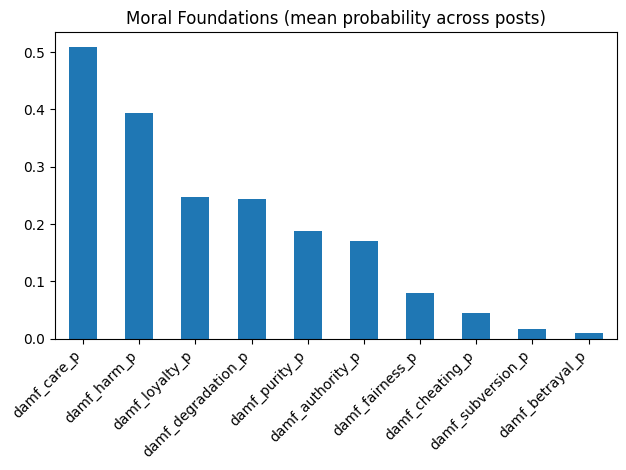

In [16]:
plt.figure()
mean_probs.plot(kind="bar")
plt.title("Moral Foundations (mean probability across posts)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [17]:
bin_cols = [f"damf_{x}" for x in damf_labels if f"damf_{x}" in df.columns]
if bin_cols:
    (df[bin_cols].mean().sort_values(ascending=False) * 100).round(2)
else:
    print("No binary columns found. Run the thresholding cell first.")


In [18]:
[c for c in df.columns if "utc" in c.lower() or "date" in c.lower() or "time" in c.lower() or "created" in c.lower()]

['created_dt']

In [24]:
import json
import pandas as pd

ID_COL = "id"          # you have "id", not "post_id"
TAGS_COL = "Tags"      # your tags are here

TW_LABELS = ["Medical","Mental Health","Abuse","Aggression","Sexual","Discrimination","Pregnancy","Not Applicable"]

def parse_tags(x):
    """
    Robust parsing for Tags column.
    Handles:
      - JSON-like lists: ["Medical","Abuse"]
      - Python-like lists as strings: ['Medical', 'Abuse']
      - separators: ; , |
      - single label string
      - empty/NaN
    """
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return [str(t).strip() for t in x if str(t).strip()]

    s = str(x).strip()
    if not s:
        return []

    # JSON-ish list
    if s.startswith("[") and s.endswith("]"):
        try:
            arr = json.loads(s.replace("'", '"'))
            if isinstance(arr, list):
                return [str(t).strip() for t in arr if str(t).strip()]
        except Exception:
            pass

    # split by common separators
    for sep in [";", "|", ","]:
        if sep in s:
            return [t.strip() for t in s.split(sep) if t.strip()]

    return [s]

parsed = df[TAGS_COL].apply(parse_tags)

for lab in TW_LABELS:
    df[lab] = parsed.apply(lambda lst: int(lab in lst))

# quick check: how many posts per label
df[TW_LABELS].sum().sort_values(ascending=False)


Mental Health     3550
Pregnancy         2652
Medical           1815
Abuse             1703
Sexual             918
Not Applicable     862
Discrimination     526
Aggression         196
dtype: int64

In [25]:
damf_labels = ["care","harm","fairness","cheating","loyalty","betrayal","authority","subversion","purity","degradation"]
damf_pcols = [f"damf_{x}_p" for x in damf_labels]

tw_present = [c for c in TW_LABELS if c in df.columns]
print("TW labels found:", tw_present)

rows = []
for lab in tw_present:
    sub = df[df[lab] == 1]
    if len(sub) == 0:
        continue
    row = {"tw_label": lab, "n": len(sub)}
    row.update(sub[damf_pcols].mean().to_dict())
    rows.append(row)

if not rows:
    print("No TW rows found (either Tags empty or labels not matching).")
else:
    tw_moral = pd.DataFrame(rows).sort_values("n", ascending=False)
    display(tw_moral)


TW labels found: ['Medical', 'Mental Health', 'Abuse', 'Aggression', 'Sexual', 'Discrimination', 'Pregnancy', 'Not Applicable']


,tw_label,n,damf_care_p,damf_harm_p,damf_fairness_p,damf_cheating_p,damf_loyalty_p,damf_betrayal_p,damf_authority_p,damf_subversion_p,damf_purity_p,damf_degradation_p
1,Mental Health,3550,0.519977,0.433386,0.078629,0.041701,0.244758,0.008927,0.166078,0.013912,0.189742,0.262438
6,Pregnancy,2652,0.529277,0.270035,0.061415,0.030773,0.203995,0.007085,0.139380,0.014520,0.249452,0.110133
0,Medical,1815,0.479672,0.275630,0.041363,0.023557,0.145429,0.006198,0.116846,0.014301,0.281708,0.107614
2,Abuse,1703,0.493780,0.642513,0.102571,0.060852,0.303743,0.012348,0.227194,0.015407,0.104930,0.465759
4,Sexual,918,0.473682,0.591145,0.080210,0.045435,0.266367,0.009278,0.194762,0.013115,0.110064,0.442628
7,Not Applicable,862,0.535679,0.296316,0.106799,0.078483,0.335187,0.014344,0.210246,0.026567,0.189105,0.217078
5,Discrimination,526,0.618736,0.496586,0.155526,0.057240,0.329699,0.013480,0.298928,0.023343,0.183261,0.360441
3,Aggression,196,0.530235,0.698316,0.101225,0.079597,0.321115,0.013482,0.307394,0.016458,0.132826,0.402455


In [26]:
damf_labels = ["care","harm","fairness","cheating","loyalty","betrayal","authority","subversion","purity","degradation"]
pcols = [f"damf_{x}_p" for x in damf_labels]

tw_moral2 = tw_moral.copy()

def topk_row(row, k=3):
    vals = row[pcols].sort_values(ascending=False).head(k)
    return ", ".join([f"{c.replace('damf_','').replace('_p','')}={v:.3f}" for c, v in vals.items()])

tw_moral2["top3_moral"] = tw_moral2.apply(topk_row, axis=1)
tw_moral2[["tw_label","n","top3_moral"]]


,tw_label,n,top3_moral
1,Mental Health,3550,"care=0.520, harm=0.433, degradation=0.262"
6,Pregnancy,2652,"care=0.529, harm=0.270, purity=0.249"
0,Medical,1815,"care=0.480, purity=0.282, harm=0.276"
2,Abuse,1703,"harm=0.643, care=0.494, degradation=0.466"
4,Sexual,918,"harm=0.591, care=0.474, degradation=0.443"
7,Not Applicable,862,"care=0.536, loyalty=0.335, harm=0.296"
5,Discrimination,526,"care=0.619, harm=0.497, degradation=0.360"
3,Aggression,196,"harm=0.698, care=0.530, degradation=0.402"


In [27]:
baseline_label = "Not Applicable"
base = tw_moral[tw_moral["tw_label"] == baseline_label].iloc[0]

delta_rows = []
for _, row in tw_moral.iterrows():
    lab = row["tw_label"]
    if lab == baseline_label:
        continue
    d = {"tw_label": lab, "n": int(row["n"])}
    for c in pcols:
        d[c.replace("_p","_delta_vs_NA")] = row[c] - base[c]
    delta_rows.append(d)

tw_delta = pd.DataFrame(delta_rows)

# show biggest positive deltas in harm & degradation (often interesting for TW)
tw_delta[["tw_label","n","damf_harm_delta_vs_NA","damf_degradation_delta_vs_NA","damf_care_delta_vs_NA"]].sort_values(
    "damf_harm_delta_vs_NA", ascending=False
)


,tw_label,n,damf_harm_delta_vs_NA,damf_degradation_delta_vs_NA,damf_care_delta_vs_NA
6,Aggression,196,0.402000,0.185377,-0.005443
3,Abuse,1703,0.346198,0.248681,-0.041899
4,Sexual,918,0.294829,0.225550,-0.061997
5,Discrimination,526,0.200271,0.143363,0.083057
0,Mental Health,3550,0.137071,0.045360,-0.015702
2,Medical,1815,-0.020686,-0.109464,-0.056007
1,Pregnancy,2652,-0.026280,-0.106945,-0.006401


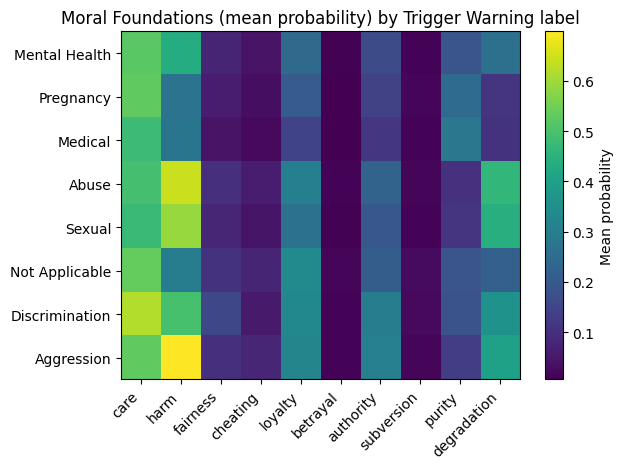

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Order labels by n (already sorted in your screenshot, but ensure)
plot_df = tw_moral.sort_values("n", ascending=False).copy()

M = plot_df[pcols].to_numpy()
labels_y = plot_df["tw_label"].tolist()
labels_x = [c.replace("damf_","").replace("_p","") for c in pcols]

plt.figure()
plt.imshow(M, aspect="auto")
plt.xticks(range(len(labels_x)), labels_x, rotation=45, ha="right")
plt.yticks(range(len(labels_y)), labels_y)
plt.colorbar(label="Mean probability")
plt.title("Moral Foundations (mean probability) by Trigger Warning label")
plt.tight_layout()
plt.show()


## Emotion Analysis

In [10]:
import os, sys, json
import pandas as pd
import numpy as np

# Assumes df already exists and has a "text" column and ID_COL from earlier cells.
print("ID_COL:", ID_COL)
print("Has text?", "text" in df.columns, "Rows:", len(df))

# Your semeval extraction folder from earlier
OUT_DIR = "semeval_pretrained"
PRETRAINED_FOLDER = os.path.join(OUT_DIR, "semeval")  # <- IMPORTANT

print("PRETRAINED_FOLDER:", PRETRAINED_FOLDER)
print("Exists?", os.path.exists(PRETRAINED_FOLDER))
if os.path.exists(PRETRAINED_FOLDER):
    print("Files:", os.listdir(PRETRAINED_FOLDER))


ID_COL: post_id
Has text? True Rows: 4994
PRETRAINED_FOLDER: semeval_pretrained/semeval
Exists? True
Files: ['model.pt', 'config.json', 'README.md']


In [11]:
import pathlib, re

trainer_path = pathlib.Path("Demux-MEmo/emorec/trainer.py")
txt = trainer_path.read_text(encoding="utf-8")

txt2 = re.sub(
    r"from transformers\.optimization import get_linear_schedule_with_warmup, AdamW",
    "from transformers.optimization import get_linear_schedule_with_warmup\nfrom torch.optim import AdamW",
    txt
)

if txt == txt2:
    print("Patch pattern not found. Showing first 50 lines so we can patch manually if needed:")
    print("\n".join(txt.splitlines()[:50]))
else:
    trainer_path.write_text(txt2, encoding="utf-8")
    print("✅ Patched:", trainer_path)


Patch pattern not found. Showing first 50 lines so we can patch manually if needed:
import logging
from typing import Optional, Union, Dict, List, Iterable, Any, Tuple
from abc import ABC, abstractmethod

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import precision_recall_fscore_support
from tqdm import tqdm
from transformers.optimization import get_linear_schedule_with_warmup
from torch.optim import AdamW

from emorec.utils import flatten_list
from emorec.train_utils import EarlyStopping
from emorec.logging_utils import ExperimentHandler


def result_str(results: Dict[str, float]):
    return ", ".join(
        [
            f"{key}={value:.4f}"
            if isinstance(value, float)
            else f"{key}={value}"
            for key, value in results.items()
        ]
    )


class BaseTrainer(ABC):
    """Trainer class for Twitter-201{5, 7} TMSC.

    Attributes:
        model: the model to train.
  

In [12]:
EMO_IN = "emo_input.csv"

emo_in_df = df[[ID_COL, "text"]].rename(columns={ID_COL: "id"})[["id", "text"]]
emo_in_df.to_csv(EMO_IN, index=False)

print("Wrote:", EMO_IN, "Rows:", len(emo_in_df))
emo_in_df.head(2)


Wrote: emo_input.csv Rows: 4994


,id,text
0,0,"Complications after abortion?\n\nHi everyone, ..."
1,1,Second MA abortion today and I'm absolutely te...


In [13]:
import glob
cfgs = glob.glob("Demux-MEmo/emotion_configs/*.json")
print("Configs:", cfgs)

EMO_CFG = None
for c in cfgs:
    if "semeval" in c.lower():
        EMO_CFG = c
        break

print("Using EMO_CFG:", EMO_CFG)
assert EMO_CFG is not None, "Could not find SemEval config."


Configs: ['Demux-MEmo/emotion_configs/paletz_revised.json', 'Demux-MEmo/emotion_configs/goemotions.json', 'Demux-MEmo/emotion_configs/semeval2018task1.json', 'Demux-MEmo/emotion_configs/paletz.json']
Using EMO_CFG: Demux-MEmo/emotion_configs/semeval2018task1.json


In [14]:
import pandas as pd

emo_in = pd.read_csv("emo_input.csv")
lens = emo_in["text"].fillna("").astype(str).str.len()

print("Rows:", len(emo_in))
print("Avg chars:", int(lens.mean()))
print("Max chars:", int(lens.max()))
print("95th pct chars:", int(lens.quantile(0.95)))


Rows: 4994
Avg chars: 1751
Max chars: 33552
95th pct chars: 5234


In [15]:
MAX_CHARS = 3000

emo_in["text"] = emo_in["text"].fillna("").astype(str).str.slice(0, MAX_CHARS)
emo_in.to_csv("emo_input_trunc.csv", index=False)

print("Wrote emo_input_trunc.csv with max chars =", MAX_CHARS)


Wrote emo_input_trunc.csv with max chars = 3000


In [69]:
import os, sys, subprocess
import pandas as pd

PRETRAINED_FOLDER = "semeval_pretrained/semeval"
EMO_CFG = "Demux-MEmo/emotion_configs/semeval2018task1.json"
PY = sys.executable

IN_PATH = "emo_input_trunc.csv"
OUT_DIR = "emo_chunks"
os.makedirs(OUT_DIR, exist_ok=True)

chunk_size = 150  # good default for CPU + long text
df_in = pd.read_csv(IN_PATH)
n = len(df_in)
print("Total rows:", n, "| chunk_size:", chunk_size, "| chunks:", (n + chunk_size - 1)//chunk_size)

for start in range(0, n, chunk_size):
    end = min(start + chunk_size, n)
    part = df_in.iloc[start:end]
    part_path = os.path.join(OUT_DIR, f"emo_in_{start:06d}_{end:06d}.csv")
    out_path  = os.path.join(OUT_DIR, f"emo_out_{start:06d}_{end:06d}.jsonl")

    if os.path.exists(out_path) and os.path.getsize(out_path) > 0:
        print(f"Skipping {start}-{end} (already done)")
        continue

    part.to_csv(part_path, index=False)

    cmd = [
        PY, "Demux-MEmo/annotate.py",
        "--pretrained-folder", PRETRAINED_FOLDER,
        "--emotion-config", EMO_CFG,
        "--domain", "twitter",
        "--input-filename", part_path,
        "--out", out_path,
        "--device", "cpu",
        "--text-column", "text",
        "--id-column", "id",
    ]

    print(f"\nRunning chunk {start}-{end}")
    res = subprocess.run(cmd, capture_output=True, text=True)

    if res.returncode != 0:
        print("❌ Failed chunk", start, end)
        print("STDERR (first 1500 chars):\n", res.stderr[:1500])
        break
    else:
        print("✅ Done chunk", start, end, "| bytes:", os.path.getsize(out_path))


Total rows: 4994 | chunk_size: 150 | chunks: 34

Running chunk 0-150
✅ Done chunk 0 150 | bytes: 254130

Running chunk 150-300
✅ Done chunk 150 300 | bytes: 263415

Running chunk 300-450
✅ Done chunk 300 450 | bytes: 236868

Running chunk 450-600
✅ Done chunk 450 600 | bytes: 275608

Running chunk 600-750
✅ Done chunk 600 750 | bytes: 286829

Running chunk 750-900
✅ Done chunk 750 900 | bytes: 290765

Running chunk 900-1050
✅ Done chunk 900 1050 | bytes: 298901

Running chunk 1050-1200
✅ Done chunk 1050 1200 | bytes: 305372

Running chunk 1200-1350
✅ Done chunk 1200 1350 | bytes: 286868

Running chunk 1350-1500
✅ Done chunk 1350 1500 | bytes: 293852

Running chunk 1500-1650
✅ Done chunk 1500 1650 | bytes: 303450

Running chunk 1650-1800
✅ Done chunk 1650 1800 | bytes: 293720

Running chunk 1800-1950
✅ Done chunk 1800 1950 | bytes: 262329

Running chunk 1950-2100
✅ Done chunk 1950 2100 | bytes: 283260

Running chunk 2100-2250
✅ Done chunk 2100 2250 | bytes: 307885

Running chunk 2250-24

In [16]:
import glob, shutil, os

chunk_files = sorted(glob.glob("emo_chunks/emo_out_*.jsonl"))
print("Chunk files:", len(chunk_files))

EMO_OUT = os.path.abspath("emo_annotations.jsonl")
with open(EMO_OUT, "w", encoding="utf-8") as w:
    for fp in chunk_files:
        with open(fp, "r", encoding="utf-8") as r:
            shutil.copyfileobj(r, w)

print("Wrote:", EMO_OUT, "| bytes:", os.path.getsize(EMO_OUT))


Chunk files: 34
Wrote: /home/ubuntu/TW_MultiLabel_SMP/jupyter-notebooks/emo_annotations.jsonl | bytes: 9373353


## Load emotion outputs & map to your target emotions

In [17]:
import json, pandas as pd

def read_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return pd.DataFrame(json.loads(line) for line in f)

emo_df = read_jsonl(EMO_OUT)
print("emo rows:", len(emo_df))
emo_df.head(2)


emo rows: 4994


,id,text,providerName,emotions
0,1ljxynj,"Complications after abortion?\n\nHi everyone, ...",ta1-usc-isi,"{'anger': 0.512080729007721, 'anticipation': 0..."
1,1ljxtt8,Second MA abortion today and I'm absolutely te...,ta1-usc-isi,"{'anger': 0.5254529118537903, 'anticipation': ..."


In [18]:
import pandas as pd

# Expand dict column "emotions" -> columns emo_<name>_p
prob_mat = emo_df["emotions"].apply(pd.Series)
prob_mat.columns = [f"emo_{c}_p" for c in prob_mat.columns]

emo_df2 = pd.concat([emo_df.drop(columns=["emotions"]), prob_mat], axis=1)

print("Expanded cols (sample):", [c for c in emo_df2.columns if c.startswith("emo_") and c.endswith("_p")][:20])
emo_df2.head(2)


Expanded cols (sample): ['emo_anger_p', 'emo_anticipation_p', 'emo_disgust_p', 'emo_fear_p', 'emo_joy_p', 'emo_love_p', 'emo_optimism_p', 'emo_pessimism_p', 'emo_sadness_p', 'emo_surprise_p', 'emo_trust_p']


,id,text,providerName,emo_anger_p,emo_anticipation_p,emo_disgust_p,emo_fear_p,emo_joy_p,emo_love_p,emo_optimism_p,emo_pessimism_p,emo_sadness_p,emo_surprise_p,emo_trust_p
0,1ljxynj,"Complications after abortion?\n\nHi everyone, ...",ta1-usc-isi,0.512081,0.315163,0.527432,0.772821,0.167779,0.054165,0.162189,0.390002,0.793129,0.220633,0.061817
1,1ljxtt8,Second MA abortion today and I'm absolutely te...,ta1-usc-isi,0.525453,0.314046,0.470785,0.939602,0.101736,0.049164,0.093843,0.313091,0.637064,0.179233,0.056005


In [19]:
import numpy as np

TARGET_EMOS = {
    "fear": ["fear"],
    "anger": ["anger"],
    "enjoyment": ["joy", "enjoyment"],
    "sadness": ["sadness"],
    "disgust_contempt": ["disgust"],
}

for tgt, aliases in TARGET_EMOS.items():
    found = None
    for a in aliases:
        col = f"emo_{a}_p"
        if col in emo_df2.columns:
            found = col
            break
    if found is None:
        print(f"WARNING: Missing probs for {tgt} (looked for {aliases})")
        emo_df2[f"emo_{tgt}_p"] = np.nan
    else:
        emo_df2[f"emo_{tgt}_p"] = pd.to_numeric(emo_df2[found], errors="coerce")

emo_df2[["id"] + [f"emo_{k}_p" for k in TARGET_EMOS.keys()]].head(5)


,id,emo_fear_p,emo_anger_p,emo_enjoyment_p,emo_sadness_p,emo_disgust_contempt_p
0,1ljxynj,0.772821,0.512081,0.167779,0.793129,0.527432
1,1ljxtt8,0.939602,0.525453,0.101736,0.637064,0.470785
2,1ljwhkb,0.210897,0.604450,0.120456,0.262414,0.623317
3,1ljvy6u,0.760879,0.262277,0.212831,0.240086,0.358812
4,1ljv5k4,0.789073,0.506200,0.095736,0.887532,0.598065


In [20]:
EMO_THRESHOLD = 0.50

for k in TARGET_EMOS.keys():
    emo_df2[f"emo_{k}"] = (emo_df2[f"emo_{k}_p"] >= EMO_THRESHOLD).astype(int)

emo_df2[["id"] + [f"emo_{k}" for k in TARGET_EMOS.keys()]].head(5)


,id,emo_fear,emo_anger,emo_enjoyment,emo_sadness,emo_disgust_contempt
0,1ljxynj,1,1,0,1,1
1,1ljxtt8,1,1,0,1,0
2,1ljwhkb,0,1,0,0,1
3,1ljvy6u,1,0,0,0,0
4,1ljv5k4,1,1,0,1,1


In [22]:
print("df[ID_COL] dtype:", df[ID_COL].dtype)
print("emo_df2['id'] dtype:", emo_df2["id"].dtype)

df[[ID_COL]].head(3), emo_df2[["id"]].head(3)


df[ID_COL] dtype: int64
emo_df2['id'] dtype: object


(   post_id
 0        0
 1        1
 2        2,
         id
 0  1ljxynj
 1  1ljxtt8
 2  1ljwhkb)

In [23]:
df[ID_COL] = df[ID_COL].astype(str)
emo_df2["id"] = emo_df2["id"].astype(str)


In [25]:
# show likely id columns + a couple sample values
cands = [c for c in df.columns if c.lower() in ["id", "post_id", "reddit_id", "fullname", "name"]]
print("Candidate ID columns:", cands)

for c in cands:
    print("\n", c, "dtype:", df[c].dtype)
    print(df[c].head(3).tolist())


Candidate ID columns: ['id', 'post_id']

 id dtype: object
['1ljxynj', '1ljxtt8', '1ljwhkb']

 post_id dtype: object
['0', '1', '2']


In [26]:
MERGE_KEY = "id"   # change if your real reddit-id column has a different name


In [27]:
df[MERGE_KEY] = df[MERGE_KEY].astype(str)
emo_df2["id"] = emo_df2["id"].astype(str)


In [28]:
keep_cols = ["id"] + [f"emo_{k}_p" for k in TARGET_EMOS.keys()] + [f"emo_{k}" for k in TARGET_EMOS.keys()]
df_emo = emo_df2[keep_cols].copy()

df = df.merge(df_emo, left_on=MERGE_KEY, right_on="id", how="left", suffixes=("", "_emo"))

# drop the right-side id ONLY if it exists
if "id_emo" in df.columns:
    df = df.drop(columns=["id_emo"])
elif "id" in df.columns and MERGE_KEY != "id":
    # if df already had its own "id" and we merged in another "id"
    # this case depends on your columns; we'll handle carefully:
    pass

df[[MERGE_KEY] + [f"emo_{k}_p" for k in TARGET_EMOS.keys()]].head(5)


,id,emo_fear_p,emo_anger_p,emo_enjoyment_p,emo_sadness_p,emo_disgust_contempt_p
0,1ljxynj,0.772821,0.512081,0.167779,0.793129,0.527432
1,1ljxtt8,0.939602,0.525453,0.101736,0.637064,0.470785
2,1ljwhkb,0.210897,0.604450,0.120456,0.262414,0.623317
3,1ljvy6u,0.760879,0.262277,0.212831,0.240086,0.358812
4,1ljv5k4,0.789073,0.506200,0.095736,0.887532,0.598065


In [29]:
probe = f"emo_{list(TARGET_EMOS.keys())[0]}_p"
print("Match rate:", df[probe].notna().mean())


Match rate: 1.0


In [30]:
emo_pcols = ["emo_fear_p", "emo_anger_p", "emo_enjoyment_p", "emo_sadness_p", "emo_disgust_contempt_p"]

df[emo_pcols].describe().T[["mean", "std", "min", "50%", "max"]].sort_values("mean", ascending=False)


,mean,std,min,50%,max
emo_anger_p,0.608123,0.188209,0.014834,0.619935,0.976281
emo_sadness_p,0.603970,0.160723,0.019825,0.591760,0.987558
emo_disgust_contempt_p,0.561201,0.158273,0.015740,0.563468,0.972433
emo_fear_p,0.361094,0.185299,0.010311,0.318466,0.978982
emo_enjoyment_p,0.295957,0.175911,0.022588,0.264088,0.989128


In [32]:
import numpy as np

emo_map = {
    "emo_fear_p": "fear",
    "emo_anger_p": "anger",
    "emo_enjoyment_p": "enjoyment",
    "emo_sadness_p": "sadness",
    "emo_disgust_contempt_p": "disgust_contempt",
}

tmp = df[["id"] + emo_pcols].copy()
tmp["emo_top_col"] = tmp[emo_pcols].idxmax(axis=1)
tmp["emo_top_label"] = tmp["emo_top_col"].map(emo_map)

# vectorized: get the probability from the selected top column
arr = tmp[emo_pcols].to_numpy()
col_idx = np.array([emo_pcols.index(c) for c in tmp["emo_top_col"]])
tmp["emo_top_p"] = arr[np.arange(len(tmp)), col_idx]

tmp[["id", "emo_top_label", "emo_top_p"]].head(10)


,id,emo_top_label,emo_top_p
0,1ljxynj,sadness,0.793129
1,1ljxtt8,fear,0.939602
2,1ljwhkb,disgust_contempt,0.623317
3,1ljvy6u,fear,0.760879
4,1ljv5k4,sadness,0.887532
5,1ljur0m,anger,0.655317
6,1ljt6uu,fear,0.964235
7,1ljt6m4,sadness,0.778688
8,1ljszrx,fear,0.953364
9,1ljpyw1,sadness,0.650384
